# QUBO — Enkodovanje ograničenja

**Quadratic Unconstrained Binary Optimization (QUBO)** je, po samoj definiciji, **bez ograničenja** (*unconstrained*). Ipak, gotovo svi realni optimizacioni problemi imaju ograničenja — npr. ukupna težina odabranih predmeta ne sme da pređe određenu vrednost, ili tačno *k* radnika mora biti raspoređeno na smenu.

Kako pomiriti ova dva zahteva?

Odgovor leži u **metodi kazne (penalty method)**: svako ograničenje se pretvara u dodatni kvadratni izraz koji se dodaje funkciji cilja. Kada je ograničenje zadovoljeno, ovaj izraz daje 0 (nema kazne); kada je narušeno, daje pozitivnu vrednost (kazna), čime rešenje postaje manje atraktivno za solversku proceduru.

Ovaj notebook sistematski objašnjava sve standardne tipove ograničenja:

| # | Tip ograničenja | Primer |
|---|---|---|
| 2 | Jednakosno | $\sum a_i x_i = b$ |
| 3 | Kardinalnosno | Tačno / Najviše / Najmanje $k$ od $n$ |
| 4 | Logičko | AND, OR, NOT, implikacija |
| 5 | Nejednakosno | $\sum a_i x_i \leq B$ |
| 6 | Kombinovano | Više ograničenja zajedno |


## 1. Metoda kazne (Penalty Method)

### Opšti princip

Pretpostavimo da imamo optimizacioni problem:

$$\min_{\mathbf{x}} \; f(\mathbf{x}) \quad \text{uz uslov} \quad g(\mathbf{x}) = 0$$

Transformišemo ga u **neograničeni** problem dodavanjem kaznenog člana:

$$\min_{\mathbf{x}} \; f(\mathbf{x}) + P \cdot g(\mathbf{x})^2$$

gde je $P > 0$ **težina kazne** (*penalty weight*).

- Kada je $g(\mathbf{x}) = 0$ (ograničenje zadovoljeno) → kazna = **0**, cilj se ne menja
- Kada je $g(\mathbf{x}) \neq 0$ (ograničenje narušeno) → kazna = $P \cdot g(\mathbf{x})^2 > 0$, rešenje je kažnjeno

### Kako odabrati $P$?

Pravilo palca:

$$\boxed{P > \max_{\mathbf{x} \text{ validno}} f(\mathbf{x}) - \min_{\mathbf{x} \text{ validno}} f(\mathbf{x})}$$

Kazna mora biti **veća od opsega vrednosti cilja** po svim validnim rešenjima. Time se garantuje da svako narušeno rešenje ima ukupnu energiju veću od bilo kog validnog rešenja.

### Čvrsta kazna (*tight penalty*)

Kazna je **čvrsta** ako je najmanja moguća vrednost koja još uvek garantuje ispravnost. Previše velika kazna je numerički nestabilna i može otežati nalaženje rešenja simuliranim žarenjem (solver "zagleda" u kaznene termine i zanemaruje cilj). Preporučuje se:

$$P = (|f_{\max}| + |f_{\min}|) \cdot 1.1 + \epsilon$$

### Zašto $g^2$, a ne $|g|$?

Kvadrat $g^2$ je **polinomijalan** u binarnim promenljivama, što omogućava QUBO formulaciju. Apsolutna vrednost $|g|$ nije polinomijalna i teška je za enkodovanje.


In [1]:
import numpy as np
import dimod
import neal
import matplotlib.pyplot as plt
import itertools
import math

# Solvers
exact = dimod.ExactSolver()          # Pregleda sva 2^n rešenja — koristimo za male probleme
sa    = neal.SimulatedAnnealingSampler()  # Simulirano žarenje — za veće probleme

print(f'dimod verzija: {dimod.__version__}')
print(f'neal  verzija: {neal.__version__}')
print('Solvers inicijalizovani.')


dimod verzija: 0.12.21
neal  verzija: 0.6.0
Solvers inicijalizovani.


## 2. Jednakosna ograničenja — $\sum_i a_i x_i = b$

### Izvođenje QUBO koeficijenata

Dato ograničenje: $\displaystyle\sum_{i=1}^{n} a_i x_i = b$

**Korak 1:** Formiramo kazneni izraz:
$$C(\mathbf{x}) = P \left(\sum_i a_i x_i - b\right)^2$$

**Korak 2:** Razvijamo kvadrat:
$$C(\mathbf{x}) = P \left(\sum_i a_i^2 x_i^2 + 2\sum_{i < j} a_i a_j x_i x_j - 2b \sum_i a_i x_i + b^2\right)$$

**Korak 3:** Koristimo $x_i^2 = x_i$ (jer $x_i \in \{0, 1\}$):
$$C(\mathbf{x}) = P \sum_i (a_i^2 - 2ba_i)\, x_i + 2P \sum_{i < j} a_i a_j\, x_i x_j + P b^2$$

**QUBO koeficijenti** (bez konstantnog člana $Pb^2$):

$$\boxed{Q_{ii} = P(a_i^2 - 2b a_i), \qquad Q_{ij} = 2P a_i a_j \quad (i < j)}$$

### Intuicija kroz tabelu energija

Za $a_i = 1$ za sve $i$ i $b = k$, kazna iznosi $P(\sum x_i - k)^2$:

| $\sum x_i$ | Grešak $= \sum x_i - k$ | Kazna $= P \cdot \text{grešak}^2$ |
|---|---|---|
| $k$ | 0 | 0 |
| $k \pm 1$ | $\pm 1$ | $P$ |
| $k \pm 2$ | $\pm 2$ | $4P$ |
| $k \pm 3$ | $\pm 3$ | $9P$ |

Kazna raste **kvadratno** sa odstupanjem — rešenja koja jako narušavaju ograničenje su strogo kažnjena.


In [2]:
# ============================================================
# Primer: Odaberi predmete čija suma težina = 6
# ============================================================
weights = [1, 2, 3, 4, 2]  # težine predmeta
b       = 6                # ciljna suma
P       = 10               # kazna (veća od opsega cilja = 0, jer nema objektivne funkcije)
n       = len(weights)
var_names = [f'x{i}' for i in range(n)]

# Gradimo BQM ručno
bqm = dimod.BinaryQuadraticModel(vartype='BINARY')

# Dijagonalni elementi: Q_ii = P*(a_i^2 - 2*b*a_i)
for i in range(n):
    ai = weights[i]
    bqm.add_variable(var_names[i], P * (ai**2 - 2 * b * ai))

# Vandijagonalni elementi: Q_ij = 2*P*a_i*a_j
for i in range(n):
    for j in range(i + 1, n):
        bqm.add_interaction(var_names[i], var_names[j], 2 * P * weights[i] * weights[j])

# Konstantni pomak P*b^2 (ne menja optimizaciju, ali pomera energije)
bqm.offset += P * b**2

# Rešavamo sa ExactSolver (2^5 = 32 rešenja)
result = exact.sample(bqm)

# Prikazujemo sva rešenja sortirana po energiji
print(f"{'Rešenje':>25} | {'Suma':>5} | {'Energija':>10} | {'Validno':>8}")
print('-' * 60)

all_records = sorted(result.record, key=lambda r: r.energy)
for rec in all_records:
    sample  = dict(zip(result.variables, rec.sample))
    x_vals  = [int(sample[f'x{i}']) for i in range(n)]
    total_w = sum(weights[i] * x_vals[i] for i in range(n))
    valid   = (total_w == b)
    mark    = '  ✓ VALIDNO' if valid else ''
    print(f"  {str(x_vals):>23} | {total_w:>5} | {rec.energy:>10.1f} | {mark}")

valid_solutions = [rec for rec in all_records
                   if sum(weights[i] * int(dict(zip(result.variables, rec.sample))[f'x{i}'])
                          for i in range(n)) == b]

print(f'\nBroj validnih rešenja: {len(valid_solutions)} / {2**n}')
print(f'Sva validna rešenja imaju energiju: {valid_solutions[0].energy:.1f} (= 0 kazna)')


                  Rešenje |  Suma |   Energija |  Validno
------------------------------------------------------------
          [1, 1, 1, 0, 0] |     6 |        0.0 |   ✓ VALIDNO
          [0, 1, 0, 1, 0] |     6 |        0.0 |   ✓ VALIDNO
          [0, 0, 0, 1, 1] |     6 |        0.0 |   ✓ VALIDNO
          [1, 0, 1, 0, 1] |     6 |        0.0 |   ✓ VALIDNO
          [0, 1, 1, 0, 0] |     5 |       10.0 | 
          [0, 0, 1, 1, 0] |     7 |       10.0 | 
          [1, 1, 0, 1, 0] |     7 |       10.0 | 
          [1, 0, 0, 1, 0] |     5 |       10.0 | 
          [1, 0, 0, 1, 1] |     7 |       10.0 | 
          [0, 0, 1, 0, 1] |     5 |       10.0 | 
          [0, 1, 1, 0, 1] |     7 |       10.0 | 
          [1, 1, 0, 0, 1] |     5 |       10.0 | 
          [1, 0, 1, 0, 0] |     4 |       40.0 | 
          [1, 0, 1, 1, 0] |     8 |       40.0 | 
          [0, 0, 0, 1, 0] |     4 |       40.0 | 
          [0, 1, 0, 1, 1] |     8 |       40.0 | 
          [1, 1, 1, 0, 1] |     8 |  

## 3. Kardinalnostna ograničenja (Cardinality)

Kardinalnostna ograničenja ograničavaju **broj** odabranih promenljivih.

### 3.1 Tačno $k$ od $n$: $\displaystyle\sum_{i=1}^n x_i = k$

Specijalan slučaj jednakosnog ograničenja sa $a_i = 1$:

$$C = P\left(\sum_i x_i - k\right)^2$$

Koeficijenti:
$$Q_{ii} = P(1 - 2k), \qquad Q_{ij} = 2P \quad (i < j)$$

### 3.2 Najviše $k$ od $n$: $\displaystyle\sum_{i=1}^n x_i \leq k$

Nejednakosno ograničenje se ne može direktno kvadrirati. Uvodimo **slack promenljivu** $s \geq 0$ koja popunjava razliku:

$$\sum_i x_i + s = k, \quad s \in \{0, 1, \ldots, k\}$$

**Binarno enkodovanje** slack promenljive (efikasnije od unarne):
$$s = \sum_{j=0}^{m-1} 2^j \cdot s_j, \quad m = \lceil \log_2(k+1) \rceil \text{ bita}$$

Ograničenje postaje jednakosno:
$$\sum_i x_i + \sum_j 2^j s_j = k$$

Koeficijenti (sa koeficijentima $a_i = 1$ za $x_i$ i $a_{n+j} = 2^j$ za $s_j$, $b = k$):
$$Q_{ii} = P(1 - 2k), \quad Q_{(n+j)(n+j)} = P(4^j - 2k \cdot 2^j), \quad Q_{ij} = 2P \cdot a_i a_j$$

### 3.3 Najmanje $k$ od $n$: $\displaystyle\sum_{i=1}^n x_i \geq k_{\min}$

Sličan pristup, ali slack oduzimamo:

$$\sum_i x_i - s = k_{\min}, \quad s \in \{0, 1, \ldots, n - k_{\min}\}$$

Binarno enkodovanje:
$$s = \sum_{j=0}^{m-1} 2^j \cdot s_j, \quad m = \lceil \log_2(n - k_{\min} + 1) \rceil$$

Koeficijenti (sa $a_i = 1$ za $x_i$ i $a_{n+j} = -2^j$ za $s_j$, $b = k_{\min}$):
$$Q_{(n+j)(n+j)} = P(4^j + 2k_{\min} \cdot 2^j), \quad Q_{i(n+j)} = -2P \cdot 2^j$$


In [3]:
def build_equality_bqm(var_list, coeffs, b, P):
    """
    Gradi BQM za jednakosno ograničenje:
        P * (sum_i coeffs[i] * var_list[i] - b)^2
    """
    bqm = dimod.BinaryQuadraticModel(vartype='BINARY')
    for i, v in enumerate(var_list):
        ai = coeffs[i]
        bqm.add_variable(v, P * (ai**2 - 2 * b * ai))
    for i in range(len(var_list)):
        for j in range(i + 1, len(var_list)):
            bqm.add_interaction(var_list[i], var_list[j], 2 * P * coeffs[i] * coeffs[j])
    bqm.offset += P * b**2
    return bqm


def print_cardinality_table(result, x_vars, n, condition_func, title):
    """Štampa tabelu rezultata za kardinalnostno ograničenje."""
    print(f'\n{title}')
    print(f"{'x promenljive':>20} | {'Suma':>5} | {'Energija':>10} | {'Status':>10}")
    print('-' * 55)
    seen = set()
    count_valid = 0
    count_invalid = 0
    for rec in sorted(result.record, key=lambda r: r.energy):
        sample = dict(zip(result.variables, rec.sample))
        x_vals = tuple(int(sample[v]) for v in x_vars)
        if x_vals in seen:
            continue
        seen.add(x_vals)
        x_sum = sum(x_vals)
        valid = condition_func(x_vals)
        if valid:
            count_valid += 1
        else:
            count_invalid += 1
        # Prikazujemo prve 6 validnih i prvih 3 nevalidnih
        if (valid and count_valid <= 6) or (not valid and count_invalid <= 3):
            status = '✓' if valid else '✗'
            print(f"  {str(list(x_vals)):>18} | {x_sum:>5} | {rec.energy:>10.1f} | {status:>10}")
    if count_valid > 6 or count_invalid > 3:
        print('  ...')
    print(f'  Ukupno validnih: {count_valid} | Nevalidnih: {count_invalid}')


# ============================================================
# A) Tačno 2 od 4
# ============================================================
n, k, P = 4, 2, 5.0
x_vars = [f'x{i}' for i in range(n)]
coeffs_eq = [1] * n

bqm_exact2 = build_equality_bqm(x_vars, coeffs_eq, k, P)
result_exact2 = exact.sample(bqm_exact2)

print_cardinality_table(
    result_exact2, x_vars, n,
    condition_func=lambda xv: sum(xv) == k,
    title=f'=== Tačno {k} od {n} === (P={P})'
)

# ============================================================
# B) Najviše 2 od 4  (slack: x0+x1+x2+x3 + s0 + 2*s1 = 2)
# ============================================================
k_max = 2
num_slack = math.ceil(math.log2(k_max + 1)) if k_max > 0 else 1
s_vars_atmost = [f's{j}' for j in range(num_slack)]
s_coeffs_atmost = [2**j for j in range(num_slack)]

all_vars_atmost   = x_vars + s_vars_atmost
all_coeffs_atmost = [1]*n + s_coeffs_atmost

bqm_atmost = build_equality_bqm(all_vars_atmost, all_coeffs_atmost, k_max, P)
result_atmost = exact.sample(bqm_atmost)

print_cardinality_table(
    result_atmost, x_vars, n,
    condition_func=lambda xv: sum(xv) <= k_max,
    title=f'=== Najviše {k_max} od {n} === (slack bita: {num_slack}, P={P})'
)

# ============================================================
# C) Najmanje 2 od 4  (slack: x0+x1+x2+x3 - s0 - 2*s1 = 2)
# ============================================================
k_min = 2
max_slack_val = n - k_min
num_slack_atleast = math.ceil(math.log2(max_slack_val + 1)) if max_slack_val > 0 else 1
s_vars_atleast   = [f'r{j}' for j in range(num_slack_atleast)]
s_coeffs_atleast = [-(2**j) for j in range(num_slack_atleast)]  # negativni koeficijenti

all_vars_atleast   = x_vars + s_vars_atleast
all_coeffs_atleast = [1]*n + s_coeffs_atleast

bqm_atleast = build_equality_bqm(all_vars_atleast, all_coeffs_atleast, k_min, P)
result_atleast = exact.sample(bqm_atleast)

print_cardinality_table(
    result_atleast, x_vars, n,
    condition_func=lambda xv: sum(xv) >= k_min,
    title=f'=== Najmanje {k_min} od {n} === (slack bita: {num_slack_atleast}, P={P})'
)



=== Tačno 2 od 4 === (P=5.0)
       x promenljive |  Suma |   Energija |     Status
-------------------------------------------------------
        [1, 1, 0, 0] |     2 |        0.0 |          ✓
        [0, 1, 1, 0] |     2 |        0.0 |          ✓
        [1, 0, 1, 0] |     2 |        0.0 |          ✓
        [0, 0, 1, 1] |     2 |        0.0 |          ✓
        [0, 1, 0, 1] |     2 |        0.0 |          ✓
        [1, 0, 0, 1] |     2 |        0.0 |          ✓
        [1, 0, 0, 0] |     1 |        5.0 |          ✗
        [0, 1, 0, 0] |     1 |        5.0 |          ✗
        [1, 1, 1, 0] |     3 |        5.0 |          ✗
  ...
  Ukupno validnih: 6 | Nevalidnih: 10

=== Najviše 2 od 4 === (slack bita: 2, P=5.0)
       x promenljive |  Suma |   Energija |     Status
-------------------------------------------------------
        [1, 1, 0, 0] |     2 |        0.0 |          ✓
        [0, 1, 1, 0] |     2 |        0.0 |          ✓
        [1, 0, 1, 0] |     2 |        0.0 |         

## 4. Logička ograničenja

Logička ograničenja enkoduju Bulove relacije između binarnih promenljivih. Svako logičko ograničenje uvodi **pomoćnu promenljivu** (*ancilla* ili *auxiliary*) $z$ koja reprezuentuje izlaz logičke kapije. Ceo trik je pronaći kazneni polinom koji je 0 za validne kombinacije $(x, y, z)$ i pozitivan za nevalidne.

### 4.1 NOT: $z = \neg x$

**Validne kombinacije:** $(x, z) \in \{(0,1), (1,0)\}$

Kazneni izraz: $P(x + z - 1)^2$

Razvijanjem $(x + z - 1)^2 = x^2 + z^2 + 1 + 2xz - 2x - 2z$, koristeći $x^2=x$, $z^2=z$:

$$C_{\text{NOT}} = P(2xz - x - z + 1)$$

**QUBO koeficijenti:** $Q_{xx} = -P$, $\; Q_{zz} = -P$, $\; Q_{xz} = 2P$, $\; \text{offset} = +P$

### 4.2 AND: $z = x \wedge y$

**Validne kombinacije:** $(x, y, z) \in \{(0,0,0), (1,0,0), (0,1,0), (1,1,1)\}$

Kazneni izraz:

$$C_{\text{AND}} = P(3z + xy - 2xz - 2yz)$$

Provera: $(0,0,0)\to 0$; $(1,0,0)\to 0$; $(0,1,0)\to 0$; $(1,1,1)\to 3+1-2-2=0$ ✓  
Nevalidno: $(0,0,1)\to 3$; $(1,1,0)\to 1$; $(1,0,1)\to 3-2=1$; $(0,1,1)\to 3-2=1$ ✓

**QUBO koeficijenti:** $Q_{zz} = 3P$, $\; Q_{xy} = P$, $\; Q_{xz} = -2P$, $\; Q_{yz} = -2P$

### 4.3 OR: $z = x \vee y$

**Validne kombinacije:** $(x, y, z) \in \{(0,0,0), (1,0,1), (0,1,1), (1,1,1)\}$

Kazneni izraz:

$$C_{\text{OR}} = P(x + y + xy - 2xz - 2yz + z)$$

Provera: $(0,0,0)\to 0$; $(1,0,1)\to 1+0+0-2+0+1=0$; $(0,1,1)\to 0+1+0-0-2+1=0$; $(1,1,1)\to 1+1+1-2-2+1=0$ ✓  
Nevalidno: $(0,0,1)\to 1$; $(1,0,0)\to 1$; $(0,1,0)\to 1$; $(1,1,0)\to 3$ ✓

**QUBO koeficijenti:** $Q_{xx} = P$, $\; Q_{yy} = P$, $\; Q_{zz} = P$, $\; Q_{xy} = P$, $\; Q_{xz} = -2P$, $\; Q_{yz} = -2P$

### 4.4 Implikacija: $x \Rightarrow y$ ("ako je $x=1$, onda mora biti $y=1$")

**Validne kombinacije:** $(x, y) \in \{(0,0), (0,1), (1,1)\}$, nevalidno: $(1, 0)$

Nema potrebe za ancilla promenljivom! Kazneni izraz:

$$C_{\text{IMPL}} = P \cdot x(1 - y) = P(x - xy)$$

Provera: $(0,0)\to 0$; $(0,1)\to 0$; $(1,1)\to 0$; $(1,0)\to 1$ ✓

**QUBO koeficijenti:** $Q_{xx} = P$, $\; Q_{xy} = -P$

### Rezime logičkih ograničenja

| Operacija | Ancilla | Kazneni polinom | $Q$ koeficijenti |
|---|---|---|---|
| $z = \neg x$ | Da ($z$) | $P(2xz - x - z + 1)$ | $Q_{xx}=-P$, $Q_{zz}=-P$, $Q_{xz}=2P$ |
| $z = x \wedge y$ | Da ($z$) | $P(3z + xy - 2xz - 2yz)$ | $Q_{zz}=3P$, $Q_{xy}=P$, $Q_{xz}=-2P$, $Q_{yz}=-2P$ |
| $z = x \vee y$ | Da ($z$) | $P(x+y+z+xy-2xz-2yz)$ | $Q_{xx}=Q_{yy}=Q_{zz}=P$, $Q_{xy}=P$, $Q_{xz}=Q_{yz}=-2P$ |
| $x \Rightarrow y$ | Ne | $P(x - xy)$ | $Q_{xx}=P$, $Q_{xy}=-P$ |


In [4]:
P_logic = 1.0  # Kazna za logička ograničenja

# ============================================================
# Definišemo svako logičko ograničenje kao BQM
# ============================================================

def build_not_bqm(P=1.0):
    """z = NOT(x): C = P*(2xz - x - z + 1)"""
    bqm = dimod.BinaryQuadraticModel(vartype='BINARY')
    bqm.add_variable('x', -P)
    bqm.add_variable('z', -P)
    bqm.add_interaction('x', 'z', 2 * P)
    bqm.offset += P
    return bqm, ['x', 'z'], lambda s: int(s['z']) == (1 - int(s['x']))


def build_and_bqm(P=1.0):
    """z = AND(x, y): C = P*(3z + xy - 2xz - 2yz)"""
    bqm = dimod.BinaryQuadraticModel(vartype='BINARY')
    bqm.add_variable('z', 3 * P)
    bqm.add_interaction('x', 'y',  P)
    bqm.add_interaction('x', 'z', -2 * P)
    bqm.add_interaction('y', 'z', -2 * P)
    return bqm, ['x', 'y', 'z'], lambda s: int(s['z']) == (int(s['x']) and int(s['y']))


def build_or_bqm(P=1.0):
    """z = OR(x, y): C = P*(x + y + z + xy - 2xz - 2yz)"""
    bqm = dimod.BinaryQuadraticModel(vartype='BINARY')
    bqm.add_variable('x',  P)
    bqm.add_variable('y',  P)
    bqm.add_variable('z',  P)
    bqm.add_interaction('x', 'y',  P)
    bqm.add_interaction('x', 'z', -2 * P)
    bqm.add_interaction('y', 'z', -2 * P)
    return bqm, ['x', 'y', 'z'], lambda s: int(s['z']) == (int(s['x']) or int(s['y']))


def build_impl_bqm(P=1.0):
    """x => y: C = P*(x - xy)"""
    bqm = dimod.BinaryQuadraticModel(vartype='BINARY')
    bqm.add_variable('x',  P)
    bqm.add_interaction('x', 'y', -P)
    return bqm, ['x', 'y'], lambda s: not (int(s['x']) == 1 and int(s['y']) == 0)


# ============================================================
# Prikaz tabela istinitosti za svaku operaciju
# ============================================================
operations = [
    ('NOT  (z = ¬x)',          build_not_bqm),
    ('AND  (z = x ∧ y)',       build_and_bqm),
    ('OR   (z = x ∨ y)',       build_or_bqm),
    ('IMPL (x ⇒ y)',           build_impl_bqm),
]

for op_name, builder in operations:
    bqm, var_list, valid_check = builder(P=P_logic)
    res = exact.sample(bqm)

    header = ' | '.join(f'{v:>3}' for v in var_list)
    print(f'\n┌─── {op_name} ─── P={P_logic} ───')
    print(f'│ {header} | {"Energija":>9} | Status')
    print('│ ' + '-' * (len(header) + 20))

    for rec in sorted(res.record, key=lambda r: r.energy):
        sample = dict(zip(res.variables, rec.sample))
        vals = ' | '.join(f'{int(sample[v]):>3}' for v in var_list)
        is_valid = valid_check(sample)
        status = '✓ validno' if is_valid else '✗ narušeno'
        print(f'│ {vals} | {rec.energy:>9.1f} | {status}')
    print('└' + '─' * 40)



┌─── NOT  (z = ¬x) ─── P=1.0 ───
│   x |   z |  Energija | Status
│ -----------------------------
│   1 |   0 |       0.0 | ✓ validno
│   0 |   1 |       0.0 | ✓ validno
│   0 |   0 |       1.0 | ✗ narušeno
│   1 |   1 |       1.0 | ✗ narušeno
└────────────────────────────────────────

┌─── AND  (z = x ∧ y) ─── P=1.0 ───
│   x |   y |   z |  Energija | Status
│ -----------------------------------
│   0 |   0 |   0 |       0.0 | ✓ validno
│   1 |   0 |   0 |       0.0 | ✓ validno
│   1 |   1 |   1 |       0.0 | ✓ validno
│   0 |   1 |   0 |       0.0 | ✓ validno
│   1 |   0 |   1 |       1.0 | ✗ narušeno
│   1 |   1 |   0 |       1.0 | ✗ narušeno
│   0 |   1 |   1 |       1.0 | ✗ narušeno
│   0 |   0 |   1 |       3.0 | ✗ narušeno
└────────────────────────────────────────

┌─── OR   (z = x ∨ y) ─── P=1.0 ───
│   x |   y |   z |  Energija | Status
│ -----------------------------------
│   0 |   0 |   0 |       0.0 | ✓ validno
│   0 |   1 |   1 |       0.0 | ✓ validno
│   1 |   1 |   1 |

## 5. Ograničenja nejednakosti sa slack promenljivama

### Problem

Dato ograničenje nejednakosti:
$$\sum_{i=1}^n a_i x_i \leq B$$

**Ne možemo** direktno kvadrirati levu stranu jer je $\leq$, a ne $=$.

### Rešenje: slack promenljiva

Uvodimo nenegativnu celubrojnu slack promenljivu $s \geq 0$ koja popunjava razliku do $B$:

$$\sum_{i=1}^n a_i x_i + s = B \quad \Leftrightarrow \quad s = B - \sum_i a_i x_i \geq 0$$

Sada imamo jednakosno ograničenje koje umemo da enkodujemo.

### Binarno enkodovanje slack promenljive

Slack $s$ može uzeti vrednosti od $0$ do $B$ (u celobrojnom slučaju). Binarno enkodujemo:

$$s = \sum_{j=0}^{m-1} 2^j \cdot s_j, \quad m = \left\lceil \log_2(B + 1) \right\rceil$$

**Zašto binarno, a ne unarno?**

| Enkodovanje | Broj bita za $B=100$ | Opis |
|---|---|---|
| Unarno | 100 | $s = s_0 + s_1 + \ldots + s_{99}$ |
| Binarno | 7 | $s = s_0 + 2s_1 + 4s_2 + \ldots + 64s_6$ |

Binarno enkodovanje je **eksponencijalno efikasnije** — presudno za primenu na kvantnom hardveru gde su kubiti skupi.

### Kompletna QUBO formulacija

Sve promenljive zajedno: $\mathbf{v} = (x_1, \ldots, x_n, s_0, \ldots, s_{m-1})$

Koeficijenti: $\alpha_i = a_i$ za $x_i$, $\;\alpha_{n+j} = 2^j$ za $s_j$

QUBO koeficijenti kazne:
$$Q_{ii} = P(\alpha_i^2 - 2B\alpha_i), \qquad Q_{ij} = 2P\alpha_i\alpha_j \quad (i < j)$$

### Napomena o gornjoj granici slack-a

Ako je $\sum a_i$ ceo broj, tada $s \leq B$ uvek. Ako koeficijenti nisu celi (razlomci), potrebno je prilagoditi enkodovanje ili skalirati problem na cele brojeve.


Ukupno sati: 12 | Granica: 8
Slack bita potrebno: ceil(log2(8+1)) = ceil(log2(9)) = 4
Slack može biti 0..15 (potrebno 0..8)

BQM ima 9 promenljivih, 36 interakcija

              Zadaci |  Sati |  Broj |   Energija | Status
--------------------------------------------------------------
     [1, 1, 1, 0, 1] |     8 |     4 |      -4.00 | ✓
     [1, 0, 1, 1, 0] |     8 |     3 |      -3.00 | ✓
     [0, 1, 0, 1, 1] |     8 |     3 |      -3.00 | ✓
     [0, 1, 1, 0, 1] |     7 |     3 |      -3.00 | ✓
     [1, 0, 0, 1, 1] |     7 |     3 |      -3.00 | ✓
     [1, 1, 0, 1, 0] |     7 |     3 |      -3.00 | ✓
     [1, 1, 0, 0, 1] |     5 |     3 |      -3.00 | ✓
     [1, 0, 1, 0, 1] |     6 |     3 |      -3.00 | ✓
     [1, 1, 1, 0, 0] |     6 |     3 |      -3.00 | ✓
     [0, 0, 1, 1, 0] |     7 |     2 |      -2.00 | ✓
     [0, 1, 1, 0, 0] |     5 |     2 |      -2.00 | ✓
     [1, 0, 0, 1, 0] |     5 |     2 |      -2.00 | ✓
     [0, 0, 1, 0, 1] |     5 |     2 |      -2.00 | ✓
     [0, 0,

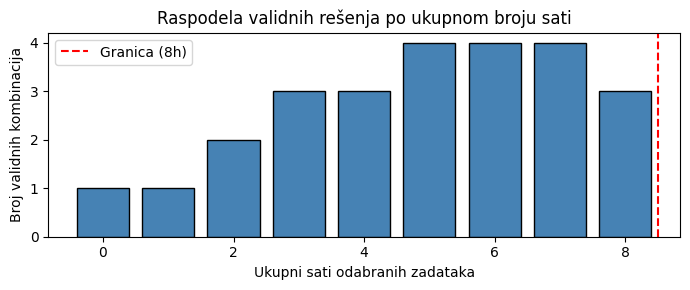

In [5]:
# ============================================================
# Primer: Raspoređivanje zadataka
# 5 zadataka sa trajanjima [1, 2, 3, 4, 2] sata
# Ograničenje: ukupno vreme <= 8 sati
# Cilj: izabrati što više zadataka (maksimizuj broj odabranih)
# ============================================================

task_hours  = [1, 2, 3, 4, 2]  # trajanje svakog zadatka u satima
max_hours   = 8                # ograničenje radnog vremena
n_tasks     = len(task_hours)
P_sched     = 20               # kazna za narušavanje ograničenja

# Koliko slack bita je potrebno?
num_slack_bits = math.ceil(math.log2(max_hours + 1))
print(f'Ukupno sati: {sum(task_hours)} | Granica: {max_hours}')
print(f'Slack bita potrebno: ceil(log2({max_hours}+1)) = ceil(log2({max_hours+1})) = {num_slack_bits}')
print(f'Slack može biti 0..{2**num_slack_bits - 1} (potrebno 0..{max_hours})')

x_task_vars = [f'x{i}' for i in range(n_tasks)]
s_slack_vars = [f's{j}' for j in range(num_slack_bits)]
all_sched_vars   = x_task_vars + s_slack_vars
all_sched_coeffs = task_hours + [2**j for j in range(num_slack_bits)]

# BQM = Cilj (minimizuj negativan broj zadataka) + Kazna (nejednakosno ograničenje)
bqm_sched = dimod.BinaryQuadraticModel(vartype='BINARY')

# Cilj: maksimizuj broj odabranih zadataka = minimizuj -sum(x_i)
for v in x_task_vars:
    bqm_sched.add_variable(v, -1.0)

# Kazna: P*(sum(h_i*x_i) + sum(2^j*s_j) - max_hours)^2
for i, v in enumerate(all_sched_vars):
    ai = all_sched_coeffs[i]
    bqm_sched.add_variable(v, P_sched * (ai**2 - 2 * max_hours * ai))
for i in range(len(all_sched_vars)):
    for j in range(i + 1, len(all_sched_vars)):
        bqm_sched.add_interaction(
            all_sched_vars[i], all_sched_vars[j],
            2 * P_sched * all_sched_coeffs[i] * all_sched_coeffs[j]
        )
bqm_sched.offset += P_sched * max_hours**2

print(f'\nBQM ima {len(bqm_sched.variables)} promenljivih, {len(bqm_sched.quadratic)} interakcija')

# Rešavamo ExactSolver-om
result_sched = exact.sample(bqm_sched)

# Prikazujemo top rešenja
print(f'\n{"Zadaci":>20} | {"Sati":>5} | {"Broj":>5} | {"Energija":>10} | Status')
print('-' * 62)

seen_sched = set()
shown = 0
for rec in sorted(result_sched.record, key=lambda r: r.energy):
    sample = dict(zip(result_sched.variables, rec.sample))
    x_vals = tuple(int(sample[f'x{i}']) for i in range(n_tasks))
    if x_vals in seen_sched:
        continue
    seen_sched.add(x_vals)
    total_h = sum(task_hours[i] * x_vals[i] for i in range(n_tasks))
    num_sel = sum(x_vals)
    valid   = (total_h <= max_hours)
    status  = '✓' if valid else '✗'
    if shown < 15:
        print(f"  {str(list(x_vals)):>18} | {total_h:>5} | {num_sel:>5} | {rec.energy:>10.2f} | {status}")
        shown += 1

# Prikaz vizuelizacije: broj validnih po dužini rada
hour_counts = {}
for x_vals in seen_sched:
    total_h = sum(task_hours[i] * x_vals[i] for i in range(n_tasks))
    if total_h <= max_hours:
        hour_counts[total_h] = hour_counts.get(total_h, 0) + 1

fig, ax = plt.subplots(figsize=(7, 3))
hs = sorted(hour_counts.keys())
ax.bar(hs, [hour_counts[h] for h in hs], color='steelblue', edgecolor='black')
ax.axvline(max_hours + 0.5, color='red', linestyle='--', label=f'Granica ({max_hours}h)')
ax.set_xlabel('Ukupni sati odabranih zadataka')
ax.set_ylabel('Broj validnih kombinacija')
ax.set_title('Raspodela validnih rešenja po ukupnom broju sati')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Ograničenja u praksi

### 6.1 Kombinovanje više ograničenja

Ako imamo $m$ ograničenja $g_1(\mathbf{x}) = 0, \ldots, g_m(\mathbf{x}) = 0$, jednostavno sabiramo sve kaznene termine:

$$f_{\text{total}}(\mathbf{x}) = f_{\text{cilj}}(\mathbf{x}) + \sum_{k=1}^m P_k \cdot g_k(\mathbf{x})^2$$

Svako ograničenje može imati **svoju kaznu** $P_k$, što daje fleksibilnost u prioritizaciji.

### 6.2 Tabela standardnih QUBO oblika ograničenja

| Tip ograničenja | Forma | QUBO kazna |
|---|---|---|
| Jednakosno | $\sum a_i x_i = b$ | $P(\sum a_i x_i - b)^2$ |
| Tačno k od n | $\sum x_i = k$ | $P(\sum x_i - k)^2$ |
| Najviše k od n | $\sum x_i \leq k$ | $P(\sum x_i + s - k)^2$, $s$ binarno enkodovan |
| Najmanje k od n | $\sum x_i \geq k$ | $P(\sum x_i - s - k)^2$, $s$ binarno enkodovan |
| Opšta nejednakost | $\sum a_i x_i \leq B$ | $P(\sum a_i x_i + s - B)^2$, $s$ binarno enkodovan |
| NOT | $z = \neg x$ | $P(2xz - x - z + 1)$ |
| AND | $z = x \wedge y$ | $P(3z + xy - 2xz - 2yz)$ |
| OR | $z = x \vee y$ | $P(x+y+z+xy-2xz-2yz)$ |
| Implikacija | $x \Rightarrow y$ | $P(x - xy)$ |

### 6.3 Kada ograničenja konflikte — detekcija neizvodljivosti

Ako su sva ograničenja previše stroga i ne postoji validno rešenje (**infeasible** problem), solver će pronaći rešenje sa pozitivnom energijom. Praktično:

```python
best_sample = result.first.sample
best_energy = result.first.energy
if best_energy > 0:
    print("Problem je neizvodljiv — nema validnih rešenja!")
```

### 6.4 CQM — Constrained Quadratic Model

`dimod` nudi i **ConstrainedQuadraticModel (CQM)** koji automatski enkoduje ograničenja, bez ručnog podešavanja kazni:

```python
import dimod

cqm = dimod.ConstrainedQuadraticModel()
x = [dimod.Binary(f'x{i}') for i in range(5)]

# Cilj
cqm.set_objective(-sum(x))

# Ograničenja
cqm.add_constraint(sum(x) == 3, label='tacno_3')
cqm.add_constraint(sum(w*xi for w, xi in zip(weights, x)) <= 7, label='tezina')

# Rešavanje sa D-Wave Hybrid Solver
# sampler = LeapHybridCQMSampler()
# result = sampler.sample_cqm(cqm)
```

CQM je preporučen za produkcijsku upotrebu, ali razumevanje penalty metode je neophodno za dublje razumevanje i za klasične solvere.


Predmeti: vrednosti=[3, 5, 2, 7, 4], težine=[2, 4, 1, 5, 3]
Ograničenje 1: tačno 3 predmeta  (P=50)
Ograničenje 2: težina <= 7           (P=30, slack bita=3)

BQM: 8 promenljivih, 28 interakcija

     Odabrani predmeti |  Br |  Tež |  Vred |   Energija | Status
--------------------------------------------------------------------
       [1, 1, 1, 0, 0] |   3 |    7 |    10 |      -10.0 | ✓ VALIDNO
       [1, 0, 1, 0, 1] |   3 |    6 |     9 |       -9.0 | ✓ VALIDNO
       [1, 0, 1, 1, 0] |   3 |    8 |    12 |       18.0 | ✗
       [0, 1, 1, 0, 1] |   3 |    8 |    11 |       19.0 | ✗
       [1, 0, 0, 1, 0] |   2 |    7 |    10 |       40.0 | ✗
       [0, 1, 0, 0, 1] |   2 |    7 |     9 |       41.0 | ✗
       [0, 0, 1, 1, 0] |   2 |    6 |     9 |       41.0 | ✗

Ukupno validnih kombinacija: 2


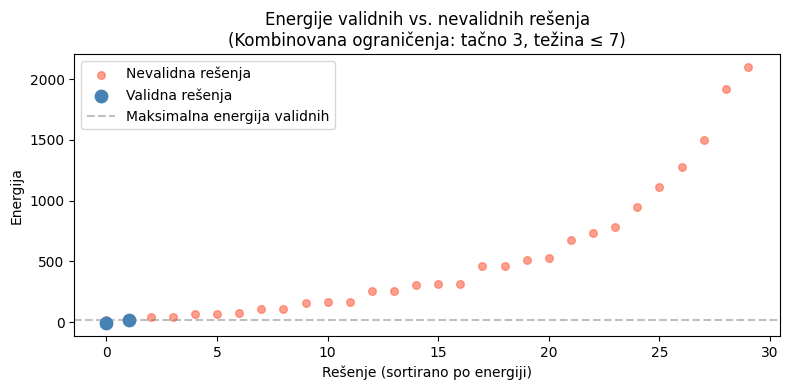

In [6]:
# ============================================================
# Primer: Kombinovana ograničenja
# 5 predmeta: vrednosti [3,5,2,7,4], težine [2,4,1,5,3]
# Cilj: maksimizuj ukupnu vrednost
# Ograničenje 1: tačno 3 predmeta (jednakosno)
# Ograničenje 2: ukupna težina <= 7 (nejednakosno)
# ============================================================

item_values  = [3, 5, 2, 7, 4]
item_weights = [2, 4, 1, 5, 3]
n_items      = len(item_values)
k_select     = 3    # tačno 3 predmeta
W_max        = 7    # maksimalna težina
P_eq         = 50   # kazna za ograničenje tačno-k
P_ineq       = 30   # kazna za ograničenje nejednakosti

x_item_vars = [f'x{i}' for i in range(n_items)]

# Slack za težinsko ograničenje
num_w_slack  = math.ceil(math.log2(W_max + 1))
w_slack_vars = [f'sw{j}' for j in range(num_w_slack)]

print(f'Predmeti: vrednosti={item_values}, težine={item_weights}')
print(f'Ograničenje 1: tačno {k_select} predmeta  (P={P_eq})')
print(f'Ograničenje 2: težina <= {W_max}           (P={P_ineq}, slack bita={num_w_slack})')

# ----- Gradimo kombinovani BQM -----
bqm_combined = dimod.BinaryQuadraticModel(vartype='BINARY')

# Cilj: maksimizuj vrednost = minimizuj negativnu vrednost
for i, v in enumerate(x_item_vars):
    bqm_combined.add_variable(v, -float(item_values[i]))

# Ograničenje 1: tačno k_select predmeta
# Kazna: P_eq * (sum(x_i) - k_select)^2
for i in range(n_items):
    bqm_combined.add_variable(x_item_vars[i], P_eq * (1 - 2 * k_select))
for i in range(n_items):
    for j in range(i + 1, n_items):
        bqm_combined.add_interaction(x_item_vars[i], x_item_vars[j], 2 * P_eq)
bqm_combined.offset += P_eq * k_select**2

# Ograničenje 2: ukupna težina <= W_max
# Enkodujemo kao: sum(w_i*x_i) + sum(2^j*sw_j) = W_max
c2_vars   = x_item_vars + w_slack_vars
c2_coeffs = item_weights + [2**j for j in range(num_w_slack)]
for i, v in enumerate(c2_vars):
    ai = c2_coeffs[i]
    bqm_combined.add_variable(v, P_ineq * (ai**2 - 2 * W_max * ai))
for i in range(len(c2_vars)):
    for j in range(i + 1, len(c2_vars)):
        bqm_combined.add_interaction(
            c2_vars[i], c2_vars[j],
            2 * P_ineq * c2_coeffs[i] * c2_coeffs[j]
        )
bqm_combined.offset += P_ineq * W_max**2

print(f'\nBQM: {len(bqm_combined.variables)} promenljivih, {len(bqm_combined.quadratic)} interakcija')

# Rešavamo
result_combined = exact.sample(bqm_combined)

# Prikazujemo
print(f'\n{"Odabrani predmeti":>22} | {"Br":>3} | {"Tež":>4} | {"Vred":>5} | {"Energija":>10} | Status')
print('-' * 68)

seen_combined = set()
valid_found   = 0
invalid_shown = 0

for rec in sorted(result_combined.record, key=lambda r: r.energy):
    sample  = dict(zip(result_combined.variables, rec.sample))
    x_vals  = tuple(int(sample[f'x{i}']) for i in range(n_items))
    if x_vals in seen_combined:
        continue
    seen_combined.add(x_vals)

    num_sel  = sum(x_vals)
    total_w  = sum(item_weights[i] * x_vals[i] for i in range(n_items))
    total_v  = sum(item_values[i]  * x_vals[i] for i in range(n_items))
    valid    = (num_sel == k_select and total_w <= W_max)

    if valid:
        valid_found += 1
        status = '✓ VALIDNO'
        print(f"  {str(list(x_vals)):>20} | {num_sel:>3} | {total_w:>4} | {total_v:>5} | {rec.energy:>10.1f} | {status}")
    elif invalid_shown < 5:
        invalid_shown += 1
        status = '✗'
        print(f"  {str(list(x_vals)):>20} | {num_sel:>3} | {total_w:>4} | {total_v:>5} | {rec.energy:>10.1f} | {status}")

print(f'\nUkupno validnih kombinacija: {valid_found}')

# Vizuelizacija: energije validnih vs nevalidnih
valid_energies   = []
invalid_energies = []
seen2 = set()
for rec in result_combined.record:
    sample = dict(zip(result_combined.variables, rec.sample))
    x_vals = tuple(int(sample[f'x{i}']) for i in range(n_items))
    if x_vals in seen2:
        continue
    seen2.add(x_vals)
    num_sel = sum(x_vals)
    total_w = sum(item_weights[i] * x_vals[i] for i in range(n_items))
    if num_sel == k_select and total_w <= W_max:
        valid_energies.append(rec.energy)
    else:
        invalid_energies.append(rec.energy)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(len(invalid_energies)), sorted(invalid_energies),
           color='tomato', alpha=0.6, s=30, label='Nevalidna rešenja')
ax.scatter(range(len(valid_energies)), sorted(valid_energies),
           color='steelblue', s=80, zorder=5, label='Validna rešenja')
ax.axhline(max(valid_energies), color='gray', linestyle='--', alpha=0.5,
           label='Maksimalna energija validnih')
ax.set_xlabel('Rešenje (sortirano po energiji)')
ax.set_ylabel('Energija')
ax.set_title('Energije validnih vs. nevalidnih rešenja\n(Kombinovana ograničenja: tačno 3, težina ≤ 7)')
ax.legend()
plt.tight_layout()
plt.show()


## Rezime

### Sve tehnike enkodovanja ograničenja

| Tip ograničenja | QUBO kazna $C(\mathbf{x})$ | Potrebne pomoćne promenljive |
|---|---|---|
| **Jednakosno** $\sum a_i x_i = b$ | $P(\sum a_i x_i - b)^2$ | — |
| **Tačno $k$ od $n$** | $P(\sum x_i - k)^2$ | — |
| **Najviše $k$ od $n$** | $P(\sum x_i + s - k)^2$ | $\lceil\log_2(k+1)\rceil$ slack bita |
| **Najmanje $k$ od $n$** | $P(\sum x_i - s - k)^2$ | $\lceil\log_2(n-k+1)\rceil$ slack bita |
| **Opšta nejednakost** $\sum a_i x_i \leq B$ | $P(\sum a_i x_i + s - B)^2$ | $\lceil\log_2(B+1)\rceil$ slack bita |
| **NOT** $z = \neg x$ | $P(2xz - x - z + 1)$ | 1 ancilla ($z$) |
| **AND** $z = x \wedge y$ | $P(3z + xy - 2xz - 2yz)$ | 1 ancilla ($z$) |
| **OR** $z = x \vee y$ | $P(x+y+z+xy-2xz-2yz)$ | 1 ancilla ($z$) |
| **Implikacija** $x \Rightarrow y$ | $P(x - xy)$ | — |

### Koeficijenti QUBO matrice za jednakosno ograničenje

Za $\sum_i a_i x_i = b$, kazna $P(\sum a_i x_i - b)^2$ daje:
$$Q_{ii} = P(a_i^2 - 2ba_i), \qquad Q_{ij} = 2Pa_ia_j \;(i<j), \qquad \text{offset} = Pb^2$$

### Ključne preporuke

1. **Kazna $P$**: Mora biti veća od opsega objektiva po validnim rešenjima. Previše mala → narušavaju se ograničenja; previše velika → numerička nestabilnost.

2. **Binarno enkodovanje slack-a**: Eksponencijalno efikasnije od unarne reprezentacije — ključno za kvantni hardver.

3. **Ancilla promenljive**: Logička ograničenja zahtevaju pomoćne binarne promenljive koje enkoduju izlaz logičke kapije.

4. **CQM za produkciju**: `dimod.ConstrainedQuadraticModel` automatizuje ceo ovaj proces i preporučen je za produkcijsku upotrebu sa D-Wave hybrid solverima.

5. **Skaliranje**: Za veće probleme (>20 promenljivih), koristite `SimulatedAnnealingSampler` ili D-Wave hardware umesto `ExactSolver`.


> **Sledeće:** Konkretne primene QUBO na realnim problemima — problem ranca, raspored, graph coloring.
